# 03. CTA + Gammapy real IRF template fit

This notebook is the third step in the workflow: it upgrades the **2D toy-map likelihood** analysis from `02_cta_map_template_fit.ipynb` to a **real CTA IRF / Gammapy map-based template-fit pipeline**.

The goal is **not** to jump directly to a strong claim such as “CTA will certainly separate the models.”  
Instead, the notebook reformulates the problem as a standard, testable analysis chain:

- generate diffusion / streaming spatial templates from a physical model;
- fold them through a real or near-real CTA IRF;
- inject one template as the truth hypothesis;
- fit the data with the competing template while allowing nuisance parameters to vary;
- quantify, using `ΔTS` or `2ΔlogL`, **under which conditions the two scenarios remain distinguishable**.

Design principles used here:

1. **First make the minimal realistic chain work end-to-end**, instead of adding every layer of complexity at once.
2. **Keep the variable definitions aligned with notebooks 01 / 02**, so that cross-checks remain transparent.
3. **Spell out the steps required by a real CTA analysis**, rather than stopping at a “Gammapy placeholder” stage.


## Recommended execution order

Run the notebook in the following order:

1. **Section 0–1**: check the environment, import packages, and define the baseline physical model.
2. **Section 2**: reproduce the 1D surface-brightness profiles used in notebook 02.
3. **Section 3**: convert the 1D profile into a 2D spatial template and export it to FITS.
4. **Section 4**: define the CTA geometry, energy axes, observation setup, and IRF input interface.
5. **Section 5**: build a `MapDataset` (or the closest realistic substitute available).
6. **Section 6**: inject a truth model and run diffusion-vs-streaming template fits.
7. **Section 7**: release nuisance parameters and repeat the tests for strong / mid / weak cases.
8. **Section 8**: run exposure / counts scans and summarize the feasibility boundary.

The first milestone to protect is **not** that every case looks clean, but that:

> the **strong** case still shows non-zero distinguishability after introducing a real IRF and basic nuisance freedom.


In [1]:
from gammapy.irf import load_irf_dict_from_file

irfs = load_irf_dict_from_file("/home/cyc/gammapy-datasets/2.0.1/cta-1dc/caldb/data/cta/1dc/bcf/South_z20_50h/irf_file.fits")

print(irfs.keys())

Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)


dict_keys(['aeff', 'psf', 'edisp', 'bkg'])


In [2]:
IRF_PATH = "/home/cyc/gammapy-datasets/2.0.1/cta-1dc/caldb/data/cta/1dc/bcf/South_z20_50h/irf_file.fits"

CTA_SITE = "South"

LIVETIME_DEFAULT = "100 h"

POINTING_ICRS = (0.0, 0.0)   # cluster center

In [3]:

# Core numerical stack
import os
from pathlib import Path
import warnings

import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.io import fits
from astropy.constants import m_p, mu0
from astropy.cosmology import Planck18 as cosmo
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

from scipy.interpolate import interp1d
from scipy.optimize import minimize
from scipy.special import ive, gammaln
import pandas as pd

warnings.filterwarnings("ignore", category=RuntimeWarning)


In [4]:
# Matplotlib compatibility patch (useful on some newer Python builds)
import matplotlib.path as mpath
import copy


def _path_deepcopy_fix(self, memo):
    cls = self.__class__
    result = cls.__new__(cls)
    memo[id(self)] = result
    for k, v in self.__dict__.items():
        setattr(result, k, copy.deepcopy(v, memo))
    result._readonly = False
    return result


mpath.Path.__deepcopy__ = _path_deepcopy_fix

In [5]:
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib as mpl
import astropy.units as u

# --- Defensive compatibility patch (useful for some Python 3.14 + Matplotlib builds) ---
# Provide safe defaults for low-level Path attributes that may be missing.
mpath.Path.should_simplify = property(lambda self: getattr(self, '_should_simplify', False))
mpath.Path.simplify_threshold = property(lambda self: getattr(self, '_simplify_threshold', mpl.rcParams['path.simplify_threshold']))
mpath.Path.interpolation_steps = property(lambda self: getattr(self, '_interpolation_steps', 1))
# ------------------------------------------------------------------


In [6]:
# Optional Gammapy import
try:
    import gammapy
    from gammapy.data import FixedPointingInfo, Observation, observatory_locations
    from gammapy.datasets import MapDataset
    from gammapy.irf import load_irf_dict_from_file
    from gammapy.makers import MapDatasetMaker
    from gammapy.maps import Map, MapAxis, WcsGeom
    from gammapy.modeling import Fit
    from gammapy.modeling.models import (
        FoVBackgroundModel,
        Models,
        PointSpatialModel,
        PowerLawSpectralModel,
        SkyModel,
        TemplateSpatialModel,
    )
    GAMMAPY_AVAILABLE = True
    print("Gammapy version:", gammapy.__version__)
except Exception as e:
    GAMMAPY_AVAILABLE = False
    print("Gammapy import failed:", repr(e))
    print("This notebook still runs in scaffold mode, but real CTA fitting sections need Gammapy.")

Gammapy version: 2.0.1


## Section 0. Environment and file layout

This section does only two things:

- make explicit where templates, IRFs, and output figures will be stored;
- confirm whether a CTA IRF file is already available in the current environment.

Typical IRF sources are:

1. **official CTA / instrument-response / local CTA production IRF files**;
2. **your own directory of Gammapy-compatible IRF products**.

Even if you do **not** yet have an IRF file, this notebook is still useful: you can first export the spatial templates to FITS, verify that the template-building chain is correct, and only then plug in the IRF layer.


In [7]:

# Directory layout
BASE_DIR = Path.cwd()
OUT_DIR = BASE_DIR / "outputs_cta_gammapy"
TPL_DIR = OUT_DIR / "templates"
FIG_DIR = OUT_DIR / "figures"
IRF_DIR = BASE_DIR / "irf"

for d in [OUT_DIR, TPL_DIR, FIG_DIR, IRF_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("BASE_DIR =", BASE_DIR)
print("OUT_DIR  =", OUT_DIR)
print("IRF_DIR  =", IRF_DIR)
print("IRF candidates:")
for p in sorted(IRF_DIR.glob("*"))[:20]:
    print(" -", p.name)


BASE_DIR = /home/cyc/Programming/CTA_practice
OUT_DIR  = /home/cyc/Programming/CTA_practice/outputs_cta_gammapy
IRF_DIR  = /home/cyc/Programming/CTA_practice/irf
IRF candidates:


## Section 1. Rebuild the physical baseline

This notebook deliberately does **not** depend on variables left in memory from the previous notebook.  
Instead, it redefines the core physical ingredients from scratch.

That makes the notebook self-contained: if you share it with someone else later, they do not need to execute notebooks 01 / 02 beforehand.


In [8]:

# Cluster / ICM baseline (keep aligned with notebook 01 / 02)
z = 0.05
R500 = 1.3 * u.Mpc
rc = 0.25 * u.Mpc
beta_gas = 0.62
ne0 = 1.0e-2 / u.cm**3
mu_e = 1.17

DA = cosmo.angular_diameter_distance(z)
Rmax = 3.0 * R500
nr = 2500
nR = 450
r = np.geomspace(1e-5, Rmax.to_value(u.Mpc), nr) * u.Mpc
Rproj = np.geomspace(1e-5, Rmax.to_value(u.Mpc), nR) * u.Mpc

theta = ((Rproj / DA).value * u.rad).to(u.deg)
theta_01 = (((0.1 * R500) / DA).value * u.rad).to(u.deg)
theta_1 = (((1.0 * R500) / DA).value * u.rad).to(u.deg)
mask_ratio = (theta >= theta_01) & (theta <= theta_1)

print(f"DA = {DA:.3f}")
print(f"theta(0.1 R500) = {theta_01:.4f}")
print(f"theta(1.0 R500) = {theta_1:.4f}")


DA = 208.509 Mpc
theta(0.1 R500) = 0.0357 deg
theta(1.0 R500) = 0.3572 deg


In [9]:

def ne_beta_model(r, ne0, rc, beta_gas):
    x = (r / rc).decompose().value
    ne = ne0 * (1.0 + x**2) ** (-1.5 * beta_gas)
    floor = 1e-6 / u.cm**3
    return np.maximum(ne.to_value(1 / u.cm**3), floor.to_value(1 / u.cm**3)) / u.cm**3


def B_profile_from_ne(ne, ne0, B0=3.0 * u.uG, eta=0.5):
    return B0 * (ne / ne0) ** eta


def alfven_speed(B, rho):
    return (B.to(u.T) / np.sqrt(mu0 * rho)).to(u.km / u.s)


def source_profile(r, rs=0.05 * u.Mpc, Q0=1.0 / u.Gyr):
    x = (r / rs).decompose().value
    return Q0.to(1 / u.s) * np.exp(-x**2)


def diffusion_coefficient_from_B(B, B0, D0=3e30 * u.cm**2 / u.s, delta_B=0.0):
    return D0 * (B / B0) ** (-delta_B)


def emissivity_hadronic(ncr, ne):
    q = ncr * ne
    qv = q.to_value(q.unit)
    qv = np.clip(qv, 0.0, None)
    return qv * q.unit


In [10]:

def solve_diffusion_profile(r, Q, D, t_loss):
    rv = r.to_value(u.cm)
    Qv = Q.to_value(1 / u.s)
    Dv = D.to_value(u.cm**2 / u.s)
    tlv = np.broadcast_to(t_loss.to_value(u.s), len(rv))

    N = len(rv)
    A = np.zeros((N, N), dtype=float)
    b = np.zeros(N, dtype=float)
    A[0, 0] = 1.0
    A[0, 1] = -1.0

    for i in range(1, N - 1):
        rimh = 0.5 * (rv[i] + rv[i - 1])
        riph = 0.5 * (rv[i] + rv[i + 1])
        dr_imh = rv[i] - rv[i - 1]
        dr_iph = rv[i + 1] - rv[i]
        dr_i = 0.5 * (rv[i + 1] - rv[i - 1])
        D_imh = 0.5 * (Dv[i] + Dv[i - 1])
        D_iph = 0.5 * (Dv[i] + Dv[i + 1])
        A_imh = rimh**2 * D_imh
        A_iph = riph**2 * D_iph
        A[i, i - 1] = A_imh / (rv[i]**2 * dr_i * dr_imh)
        A[i, i] = -(A_imh / dr_imh + A_iph / dr_iph) / (rv[i]**2 * dr_i) - 1.0 / tlv[i]
        A[i, i + 1] = A_iph / (rv[i]**2 * dr_i * dr_iph)
        b[i] = -Qv[i]

    A[-1, -1] = 1.0
    b[-1] = 0.0
    n = np.linalg.solve(A, b)
    return np.clip(n, 0.0, None) * u.dimensionless_unscaled


def solve_streaming_profile(r, Q, vstream, t_loss):
    rv = r.to_value(u.cm)
    Qv = Q.to_value(1 / u.s)
    vv = np.clip(vstream.to_value(u.cm / u.s), 1e-30, None)
    tlv = np.broadcast_to(t_loss.to_value(u.s), len(rv))

    N = len(rv)
    A = np.zeros((N, N), dtype=float)
    b = np.zeros(N, dtype=float)
    A[0, 0] = 1.0
    A[0, 1] = -1.0

    for i in range(1, N - 1):
        dr_imh = rv[i] - rv[i - 1]
        dr_i = 0.5 * (rv[i + 1] - rv[i - 1])
        flux_coeff = (rv[i - 1]**2 * vv[i - 1]) / (rv[i]**2 * dr_i)
        A[i, i - 1] = flux_coeff / dr_imh
        A[i, i] = -flux_coeff / dr_imh - 1.0 / tlv[i]
        b[i] = -Qv[i]

    A[-1, -1] = 1.0
    b[-1] = 0.0
    n = np.linalg.solve(A, b)
    return np.clip(n, 0.0, None) * u.dimensionless_unscaled


In [11]:

def surface_brightness_abel(Rproj, r3d, q3d):
    Rv = Rproj.to_value(u.Mpc)
    rv = r3d.to_value(u.Mpc)
    qv = q3d.to_value(q3d.unit)
    S = np.zeros_like(Rv)
    for i, R in enumerate(Rv):
        mask = rv > R
        rr = rv[mask]
        qq = qv[mask]
        denom = np.sqrt(np.maximum(rr**2 - R**2, 1e-30))
        S[i] = 2.0 * np.trapezoid(qq * rr / denom, rr)
    return S * (q3d.unit * u.Mpc)


def convolve_circular_gaussian(R, S, sigma):
    Rv = R.to_value(u.deg)
    Sv = S.to_value(S.unit)
    sig = sigma.to_value(u.deg)
    Rp = Rv
    Sconv = np.zeros_like(Rv)
    for i, Ri in enumerate(Rv):
        x = (Ri * Rp) / (sig**2)
        kernel = (Rp / sig**2) * np.exp(-((Ri - Rp) ** 2) / (2 * sig**2)) * ive(0, x)
        Sconv[i] = np.trapezoid(Sv * kernel, Rp)
    return Sconv * S.unit


def normalize_profile(S):
    return (S / np.max(S)).decompose()


In [12]:

def run_transport_model(rs=0.05 * u.Mpc, B0=3.0 * u.uG, eta=0.5, alpha=2.0,
                        D0=3e30 * u.cm**2 / u.s, delta_B=0.0, t_loss=5.0 * u.Gyr,
                        psf_fwhm=0.05 * u.deg, frac_floor=1e-3):
    ne = ne_beta_model(r, ne0=ne0, rc=rc, beta_gas=beta_gas)
    B = B_profile_from_ne(ne, ne0=ne0, B0=B0, eta=eta)
    rho = (mu_e * m_p * ne).to(u.kg / u.m**3)
    vA = alfven_speed(B, rho)
    Q = source_profile(r, rs=rs, Q0=1.0 / u.Gyr)
    D = diffusion_coefficient_from_B(B, B0=B0, D0=D0, delta_B=delta_B)
    vstream = alpha * vA

    ncr_D = solve_diffusion_profile(r, Q, D, t_loss=t_loss)
    ncr_S = solve_streaming_profile(r, Q, vstream, t_loss=t_loss)
    q_D = emissivity_hadronic(ncr_D, ne)
    q_S = emissivity_hadronic(ncr_S, ne)

    S_D = surface_brightness_abel(Rproj, r, q_D)
    S_S = surface_brightness_abel(Rproj, r, q_S)

    psf_sigma = (psf_fwhm / (2 * np.sqrt(2 * np.log(2)))).to(u.deg)
    S_D_psf = convolve_circular_gaussian(theta, normalize_profile(S_D), psf_sigma)
    S_S_psf = convolve_circular_gaussian(theta, normalize_profile(S_S), psf_sigma)

    S_D_psf = np.maximum(S_D_psf.value, frac_floor) * u.dimensionless_unscaled
    S_S_psf = np.maximum(S_S_psf.value, frac_floor) * u.dimensionless_unscaled
    S_D_psf = normalize_profile(S_D_psf)
    S_S_psf = normalize_profile(S_S_psf)

    ratio_ann = (S_D_psf[mask_ratio] / S_S_psf[mask_ratio]).value
    return {
        "ne": ne,
        "B": B,
        "vA": vA,
        "ncr_D": ncr_D,
        "ncr_S": ncr_S,
        "S_D": S_D,
        "S_S": S_S,
        "S_D_psf": S_D_psf,
        "S_S_psf": S_S_psf,
        "ratio_ann": ratio_ann,
        "ratio_med": float(np.median(ratio_ann)),
    }


In [13]:

param_points = [
    {"label": "weak",   "alpha": 3.0, "D0": 3e30},
    {"label": "mid",    "alpha": 2.0, "D0": 1e31},
    {"label": "strong", "alpha": 1.0, "D0": 1e31},
]

results = {}
for pp in param_points:
    out = run_transport_model(alpha=pp["alpha"], D0=pp["D0"] * u.cm**2 / u.s)
    results[pp["label"]] = out
    print(pp["label"], "ratio_med =", f"{out['ratio_med']:.3f}")


weak ratio_med = 2.938
mid ratio_med = 4.684
strong ratio_med = 4.684


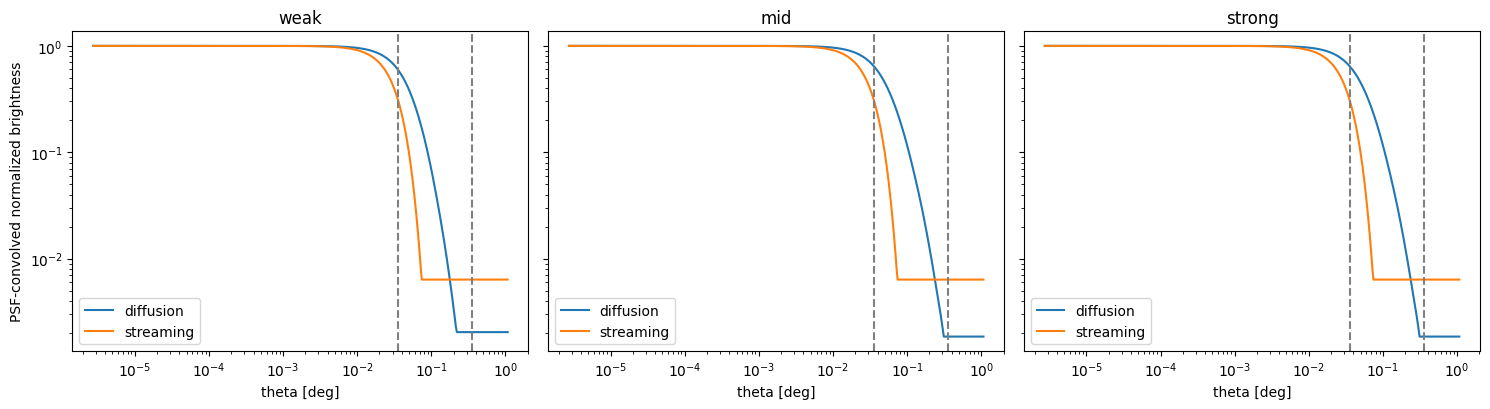

In [14]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, pp in zip(axes, param_points):
    out = results[pp["label"]]
    ax.loglog(theta.to_value(u.deg), out["S_D_psf"].value, label="diffusion")
    ax.loglog(theta.to_value(u.deg), out["S_S_psf"].value, label="streaming")
    ax.axvline(theta_01.to_value(u.deg), ls="--", color="gray")
    ax.axvline(theta_1.to_value(u.deg), ls="--", color="gray")
    ax.set_title(pp["label"])
    ax.set_xlabel("theta [deg]")
    ax.legend()
axes[0].set_ylabel("PSF-convolved normalized brightness")
plt.tight_layout()
plt.show()


## Section 2. From radial profile to 2D spatial template

The most natural input for Gammapy’s `TemplateSpatialModel` is a **2D map**.

This section therefore does three things:

1. interpolate the 1D radial profile onto a 2D plane;
2. build a normalized image template;
3. export the result to FITS so it can be used later by Gammapy, other map-based tools, or shared with collaborators.

**Important note:** the template exported here should represent the **intrinsic sky morphology**, not a morphology that has already been blurred by the CTA PSF.  
The PSF convolution is applied later by the IRF-aware dataset machinery.


In [15]:

def make_map_axis(npix=201, pixsize=0.01 * u.deg):
    half = (npix // 2) * pixsize.to_value(u.deg)
    return np.linspace(-half, half, npix)


def radial_profile_interpolator(theta_grid, S_theta):
    return interp1d(theta_grid.to_value(u.deg), np.clip(S_theta.value, 0.0, None),
                    kind="linear", bounds_error=False, fill_value=0.0)


def template_image_from_profile(theta_grid, S_theta, ax_deg, x0=0.0, y0=0.0, stretch=1.0):
    interp = radial_profile_interpolator(theta_grid, S_theta)
    xx, yy = np.meshgrid(ax_deg, ax_deg, indexing="xy")
    rr = np.sqrt((xx - x0)**2 + (yy - y0)**2) / stretch
    img = np.clip(interp(rr), 0.0, None)
    total = img.sum()
    if total <= 0:
        raise ValueError("Template image has zero total intensity.")
    return img / total


def simple_wcs(npix=201, binsz=0.01, center=SkyCoord(0, 0, unit="deg", frame="icrs")):
    w = WCS(naxis=2)
    w.wcs.crpix = [npix // 2 + 1, npix // 2 + 1]
    w.wcs.cdelt = np.array([-binsz, binsz])
    w.wcs.crval = [center.ra.deg, center.dec.deg]
    w.wcs.ctype = ["RA---TAN", "DEC--TAN"]
    return w


def save_template_fits(image, filename, binsz_deg=0.01, center=SkyCoord(0, 0, unit="deg", frame="icrs")):
    w = simple_wcs(npix=image.shape[0], binsz=binsz_deg, center=center)
    hdu = fits.PrimaryHDU(data=image.astype("float32"), header=w.to_header())
    hdu.writeto(filename, overwrite=True)
    return filename


In [16]:

npix = 201
pixsize = 0.01 * u.deg
ax_deg = make_map_axis(npix=npix, pixsize=pixsize)

export_templates = {}
for pp in param_points:
    label = pp["label"]
    out = results[label]
    # Do not use the PSF-convolved radial profiles here.
    # Otherwise the morphology would be blurred twice: once here and once again by the IRF-aware fit.
    # img_D = template_image_from_profile(theta, out["S_D_psf"], ax_deg)
    # img_S = template_image_from_profile(theta, out["S_S_psf"], ax_deg)
    img_D = template_image_from_profile(theta, normalize_profile(out["S_D"]), ax_deg)
    img_S = template_image_from_profile(theta, normalize_profile(out["S_S"]), ax_deg)

    fn_D = TPL_DIR / f"template_{label}_diffusion.fits"
    fn_S = TPL_DIR / f"template_{label}_streaming.fits"
    save_template_fits(img_D, fn_D, binsz_deg=pixsize.to_value(u.deg))
    save_template_fits(img_S, fn_S, binsz_deg=pixsize.to_value(u.deg))

    export_templates[label] = {
        "diffusion": img_D,
        "streaming": img_S,
        "diffusion_file": fn_D,
        "streaming_file": fn_S,
    }

print("Saved templates:")
for label, item in export_templates.items():
    print(label, item["diffusion_file"].name, item["streaming_file"].name)


Saved templates:
weak template_weak_diffusion.fits template_weak_streaming.fits
mid template_mid_diffusion.fits template_mid_streaming.fits
strong template_strong_diffusion.fits template_strong_streaming.fits


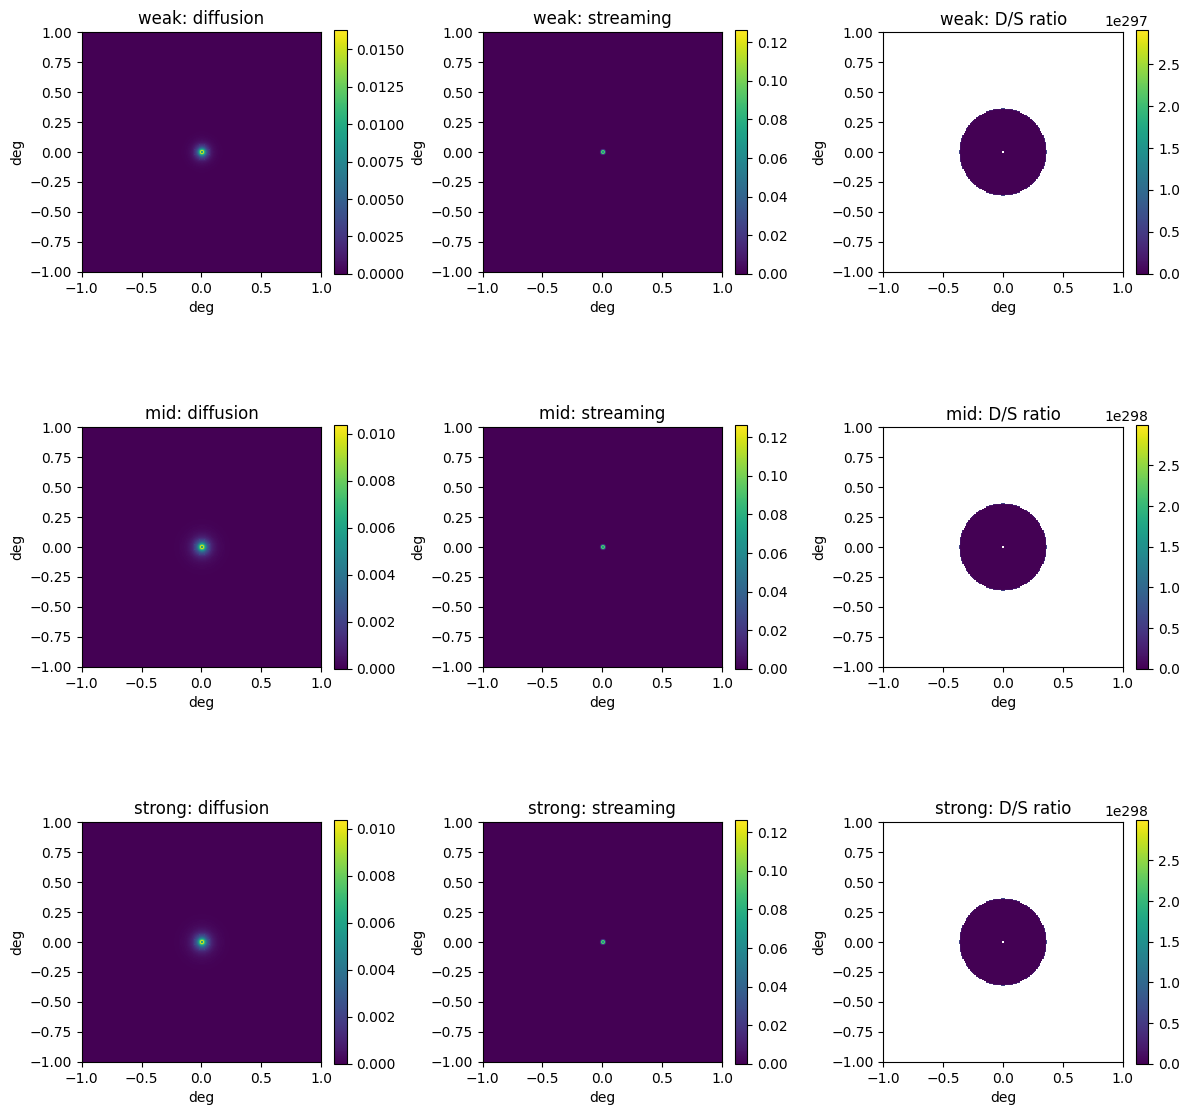

In [17]:

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
extent = [ax_deg.min(), ax_deg.max(), ax_deg.min(), ax_deg.max()]
for row, pp in enumerate(param_points):
    label = pp["label"]
    img_D = export_templates[label]["diffusion"]
    img_S = export_templates[label]["streaming"]
    ratio = np.divide(img_D, img_S, out=np.full_like(img_D, np.nan), where=img_S > 0)
    for col, (arr, ttl) in enumerate([
        (img_D, f"{label}: diffusion"),
        (img_S, f"{label}: streaming"),
        (ratio, f"{label}: D/S ratio"),
    ]):
        im = axes[row, col].imshow(arr, origin="lower", extent=extent)
        axes[row, col].set_title(ttl)
        axes[row, col].set_xlabel("deg")
        axes[row, col].set_ylabel("deg")
        plt.colorbar(im, ax=axes[row, col], fraction=0.046)
plt.tight_layout()
plt.show()


## Section 3. CTA geometry and analysis configuration

This section defines the geometric backbone required for a real map-based analysis:

- sky center
- field-of-view size
- pixel size
- reconstructed-energy axis
- true-energy axis

If you later switch to a real cluster target (Coma, Perseus, Ophiuchus, ...), the main changes will typically happen here and in the source flux normalization.


In [18]:

# Analysis configuration
sky_center = SkyCoord(0.0, 0.0, unit="deg", frame="icrs")
map_npix = 250
binsz = 0.02 * u.deg
ereco_edges = np.geomspace(0.05, 10.0, 9) * u.TeV
etrue_edges = np.geomspace(0.03, 30.0, 18) * u.TeV
livetime_ref = 100 * u.hr

print("Map npix   =", map_npix)
print("Pixel size =", binsz)
print("E reco     =", ereco_edges)
print("E true     =", etrue_edges)
print("Livetime   =", livetime_ref)


Map npix   = 250
Pixel size = 0.02 deg
E reco     = [ 0.05        0.09696137  0.18803015  0.36463324  0.70710678  1.37124088
  2.65914795  5.15669269 10.        ] TeV
E true     = [ 0.03        0.04503932  0.06761802  0.10151565  0.15240654  0.22880958
  0.34351427  0.51572166  0.77425846  1.16240254  1.7451274   2.61997849
  3.93340181  5.90525834  8.86562771 13.31006199 19.98253887 30.        ] TeV
Livetime   = 100.0 h


In [19]:

if GAMMAPY_AVAILABLE:
    energy_axis = MapAxis.from_edges(ereco_edges, interp="log", name="energy")
    energy_axis_true = MapAxis.from_edges(etrue_edges, interp="log", name="energy_true")
    geom = WcsGeom.create(
        skydir=sky_center,
        npix=(map_npix, map_npix),
        binsz=binsz,
        frame="icrs",
        axes=[energy_axis],
    )
    geom_true = WcsGeom.create(
        skydir=sky_center,
        npix=(map_npix, map_npix),
        binsz=binsz,
        frame="icrs",
        axes=[energy_axis_true],
    )
    print(geom)
else:
    geom = None
    geom_true = None
    print("Gammapy not available: geometry objects not built.")


WcsGeom

	axes       : ['lon', 'lat', 'energy']
	shape      : (np.int64(250), np.int64(250), 8)
	ndim       : 3
	frame      : icrs
	projection : CAR
	center     : 0.0 deg, 0.0 deg
	width      : 5.0 deg x 5.0 deg
	wcs ref    : 0.0 deg, 0.0 deg



## Section 4. IRF input strategy — standard Gammapy pipeline

This notebook no longer uses a placeholder approach in which exposure / PSF / edisp / background are inserted manually into the dataset.  
Instead, it follows the **standard Gammapy tutorial-style workflow**:

1. `load_irf_dict_from_file(IRF_PATH)` reads the CTA IRF;
2. `Observation.create(...)` builds an observation with pointing / livetime / site metadata;
3. `MapDataset.create(...)` creates an empty dataset;
4. `MapDatasetMaker.run(empty, observation)` fills the current geometry with:
   - counts
   - exposure
   - background
   - psf
   - edisp

Advantages of this approach:

- it stays much closer to the official Gammapy CTA 3D simulation workflow;
- it is more robust against future version changes;
- it is easier to extend later to multiple observations, real pointing offsets, and safe masks.

The main user inputs you need to provide are:

- `IRF_PATH`
- `CTA_SITE`
- `POINTING_ICRS`
- `livetime`


In [20]:
# Put your real CTA IRF file here.
IRF_PATH = "/home/cyc/gammapy-datasets/2.0.1/cta-1dc/caldb/data/cta/1dc/bcf/South_z20_50h/irf_file.fits"

# Recommended examples:
# IRF_PATH = IRF_DIR / "Prod5-South-20deg-AverageAz-14MSTs37SSTs.180000s-v0.1.fits.gz"
# IRF_PATH = Path(os.environ["GAMMAPY_DATA"]) / "cta-1dc/caldb/data/cta/1dc/bcf/South_z20_50h/irf_file.fits"

CTA_SITE = "South"   # "South" or "North"
OBS_ID = 1001
POINTING_ICRS = sky_center
LIVETIME_DEFAULT = livetime_ref

print("IRF_PATH         =", IRF_PATH)
print("Exists           =", (IRF_PATH is not None and Path(IRF_PATH).exists()))
print("CTA_SITE         =", CTA_SITE)
print("POINTING_ICRS    =", POINTING_ICRS.to_string("hmsdms"))
print("LIVETIME_DEFAULT =", LIVETIME_DEFAULT)

IRF_PATH         = /home/cyc/gammapy-datasets/2.0.1/cta-1dc/caldb/data/cta/1dc/bcf/South_z20_50h/irf_file.fits
Exists           = True
CTA_SITE         = South
POINTING_ICRS    = 00h00m00s +00d00m00s
LIVETIME_DEFAULT = 100.0 h


In [21]:
def explain_irf_expectation():
    print("Gammapy CTA checklist:")
    print("1) load_irf_dict_from_file(IRF_PATH)")
    print("2) Observation.create(pointing=..., livetime=..., irfs=..., location=...)")
    print("3) MapDataset.create(geom=..., energy_axis_true=...)")
    print("4) MapDatasetMaker(selection=['counts','exposure','background','psf','edisp']).run(...)")
    print("5) Only after this step trust realistic counts and ΔTS")

explain_irf_expectation()

Gammapy CTA checklist:
1) load_irf_dict_from_file(IRF_PATH)
2) Observation.create(pointing=..., livetime=..., irfs=..., location=...)
3) MapDataset.create(geom=..., energy_axis_true=...)
4) MapDatasetMaker(selection=['counts','exposure','background','psf','edisp']).run(...)
5) Only after this step trust realistic counts and ΔTS


## Section 5. Build spatial templates as Gammapy models

Before doing any injection or fitting, first verify that:

- the diffusion / streaming templates can be read by Gammapy as valid `TemplateSpatialModel` objects;
- there is a single minimal spectral placeholder shared across templates;
- the template image is correctly aligned with the sky center and pixel grid.

**Note:** the spectral model used here is only a working placeholder.  
For a cluster-specific forecast, the total flux normalization must be replaced by a more realistic value.


In [22]:
# Minimal spectral placeholder: only amplitude free, shape fixed
if GAMMAPY_AVAILABLE:
    spectral_template = PowerLawSpectralModel(
        index=2.3,
        amplitude=1e-13 * u.Unit("cm-2 s-1 TeV-1"),
        reference=1 * u.TeV,
    )

    # We only want morphology distinguishability for now:
    # allow overall source normalization to float,
    # but freeze spectral shape.
    spectral_template.amplitude.frozen = False
    spectral_template.index.frozen = True
    spectral_template.reference.frozen = True

    print(spectral_template)
    print("Free parameters:", [p.name for p in spectral_template.parameters if not p.frozen])
else:
    spectral_template = None

PowerLawSpectralModel

type    name     value         unit        error   min max frozen link prior
---- --------- ---------- -------------- --------- --- --- ------ ---- -----
         index 2.3000e+00                0.000e+00 nan nan   True           
     amplitude 1.0000e-13 TeV-1 s-1 cm-2 0.000e+00 nan nan  False           
     reference 1.0000e+00            TeV 0.000e+00 nan nan   True           
Free parameters: ['amplitude']


In [23]:
from pathlib import Path
from gammapy.maps import Map
from gammapy.modeling.models import (
    TemplateSpatialModel,
    SkyModel,
    PowerLawSpectralModel,
)

def build_spatial_model_from_fits(fits_path, normalize=True):
    if not GAMMAPY_AVAILABLE:
        return None

    fits_path = Path(fits_path).expanduser().resolve()
    m = Map.read(str(fits_path))

    # Keep the original filename attached at construction time.
    # This is helpful for bookkeeping and for later inspection of the model provenance.
    spatial_model = TemplateSpatialModel(
        m,
        normalize=normalize,
        filename=str(fits_path),
    )
    return spatial_model


def build_sky_model(label, mode, fits_path, spectral_model=None):
    if not GAMMAPY_AVAILABLE:
        return None

    spatial_model = build_spatial_model_from_fits(fits_path)
    spectral_model = (
        spectral_model.copy()
        if spectral_model is not None
        else PowerLawSpectralModel()
    )

    model = SkyModel(
        spatial_model=spatial_model,
        spectral_model=spectral_model,
        name=f"cluster_{label}_{mode}",
    )
    return model


In [24]:

if GAMMAPY_AVAILABLE:
    strong_diff_model = build_sky_model(
        "strong", "diffusion", export_templates["strong"]["diffusion_file"], spectral_template
    )
    strong_stream_model = build_sky_model(
        "strong", "streaming", export_templates["strong"]["streaming_file"], spectral_template
    )
    print(strong_diff_model)
    print(strong_stream_model)
else:
    print("Gammapy not available: skip model construction.")


SkyModel

  Name                      : cluster_strong_diffusion
  Datasets names            : None
  Spectral model type       : PowerLawSpectralModel
  Spatial  model type       : TemplateSpatialModel
  Temporal model type       : 
  Parameters:
    index                 (frozen):      2.300                   
    amplitude                     :   1.00e-13   +/- 0.0e+00 1 / (TeV s cm2)
    reference             (frozen):      1.000       TeV         
    lon_0                 (frozen):      0.000       deg         
    lat_0                 (frozen):      0.000       deg         


SkyModel

  Name                      : cluster_strong_streaming
  Datasets names            : None
  Spectral model type       : PowerLawSpectralModel
  Spatial  model type       : TemplateSpatialModel
  Temporal model type       : 
  Parameters:
    index                 (frozen):      2.300                   
    amplitude                     :   1.00e-13   +/- 0.0e+00 1 / (TeV s cm2)
    reference     

## Section 6. Dataset construction — Gammapy pipeline version

This section switches to the standard **Observation + MapDatasetMaker** workflow.

The core idea is:

- do **not** stuff IRFs directly into `dataset` attributes by hand;
- first construct an `Observation` carrying the IRFs;
- then let `MapDatasetMaker` build the dataset on top of the chosen geometry.

This is much closer to the official CTA 3D simulation / event-sampling workflow, and it is also better suited to later extensions such as:

- different pointing offsets
- multiple stacked observations
- safe masks
- livetime scans

Pay special attention to the following three functions:

- `create_cta_observation_from_irf()`
- `build_empty_dataset()`
- `attach_real_irfs_to_dataset()`

At this stage, `attach_real_irfs_to_dataset()` is no longer a placeholder; it is the formal entry point for building an IRF-backed dataset inside this notebook.


In [25]:
def create_cta_observation_from_irf(
    irf_path,
    livetime=100 * u.hr,
    pointing_icrs=None,
    obs_id=1001,
    site="South",
):
    '''
    Standard Gammapy CTA observation constructor.

    Parameters
    ----------
    irf_path : str or Path
        Path to a Gammapy-compatible CTA IRF FITS file.
    livetime : `~astropy.units.Quantity`
        Observation livetime.
    pointing_icrs : `~astropy.coordinates.SkyCoord`
        ICRS pointing position. Defaults to sky_center.
    obs_id : int
        Observation ID.
    site : {"South", "North"}
        Observatory site used to pick observatory location metadata.

    Returns
    -------
    observation : `gammapy.data.Observation`
        Observation carrying pointing + livetime + IRFs.
    irfs : dict
        IRF dictionary returned by `load_irf_dict_from_file`.
    '''
    if not GAMMAPY_AVAILABLE:
        raise RuntimeError("Gammapy is not available in this environment.")
    if irf_path is None:
        raise ValueError("IRF_PATH is None. Please point it to a real CTA IRF FITS file.")

    irf_path = Path(irf_path)
    if not irf_path.exists():
        raise FileNotFoundError(f"IRF file not found: {irf_path}")

    if pointing_icrs is None:
        pointing_icrs = sky_center

    irfs = load_irf_dict_from_file(irf_path)

    site_key = str(site).strip().lower()
    if site_key in {"south", "cta_south", "ctao_south"}:
        location = observatory_locations["ctao_south"]
    elif site_key in {"north", "cta_north", "ctao_north"}:
        location = observatory_locations["ctao_north"]
    else:
        raise ValueError("site must be 'South' or 'North'")

    pointing = FixedPointingInfo(fixed_icrs=pointing_icrs.icrs)

    observation = Observation.create(
        obs_id=obs_id,
        pointing=pointing,
        livetime=livetime,
        irfs=irfs,
        location=location,
    )
    return observation, irfs


def attach_real_irfs_to_dataset(
    dataset,
    irf_path,
    livetime=100 * u.hr,
    pointing_icrs=None,
    obs_id=1001,
    site="South",
    selection=None,
):
    '''
    Build a realistic CTA MapDataset using the standard Gammapy maker pipeline.

    This replaces the earlier placeholder implementation. The logic is:

        load IRFs -> create Observation -> run MapDatasetMaker on an empty MapDataset

    Parameters
    ----------
    dataset : `gammapy.datasets.MapDataset`
        Empty reference dataset defining geometry.
    irf_path : str or Path
        Path to CTA IRF FITS file.
    livetime, pointing_icrs, obs_id, site
        Observation configuration.
    selection : list[str] or None
        Passed to MapDatasetMaker. Defaults to
        ['counts', 'exposure', 'background', 'psf', 'edisp'].

    Returns
    -------
    dataset_real : `gammapy.datasets.MapDataset`
        Dataset populated with realistic IRF-derived maps.
    observation : `gammapy.data.Observation`
        Observation used to make the dataset.
    '''
    if not GAMMAPY_AVAILABLE:
        raise RuntimeError("Gammapy is not available in this environment.")
    if dataset is None:
        raise ValueError("dataset is None")
    if selection is None:
        selection = ["exposure", "background", "psf", "edisp"]

    observation, irfs = create_cta_observation_from_irf(
        irf_path=irf_path,
        livetime=livetime,
        pointing_icrs=pointing_icrs,
        obs_id=obs_id,
        site=site,
    )

    maker = MapDatasetMaker(
        selection=selection,
        background_interp_missing_data=True,
    )
    dataset_real = maker.run(dataset, observation)

    try:
        dataset_real.meta_table["irf_file"] = [str(Path(irf_path).name)]
        dataset_real.meta_table["obs_id"] = [obs_id]
        dataset_real.meta_table["livetime_hr"] = [livetime.to_value(u.hr)]
        dataset_real.meta_table["site"] = [site]
    except Exception:
        pass

    return dataset_real, observation

In [26]:
def build_empty_dataset(name="cta-cluster", livetime=100 * u.hr):
    if not GAMMAPY_AVAILABLE:
        return None
    if geom is None or energy_axis_true is None:
        raise ValueError("Geometry has not been built.")

    ds = MapDataset.create(
        geom=geom,
        energy_axis_true=energy_axis_true,
        name=name,
    )
    try:
        ds.meta_table["livetime_hr"] = [livetime.to_value(u.hr)]
    except Exception:
        pass
    return ds

In [27]:
# Standard Gammapy pipeline execution cell:
# empty dataset -> observation with IRF -> MapDatasetMaker.run(...)

if GAMMAPY_AVAILABLE:
    dataset_real = None
    observation_real = None
    try:
        dataset_real, observation_real = attach_real_irfs_to_dataset(
            build_empty_dataset(livetime=LIVETIME_DEFAULT),
            IRF_PATH,
            livetime=LIVETIME_DEFAULT,
            pointing_icrs=POINTING_ICRS,
            obs_id=OBS_ID,
            site=CTA_SITE,
            selection=["exposure", "background", "psf", "edisp"],   # Explicitly request the IRF-derived components needed below.
        )
        print(observation_real)
        print(dataset_real)
    except Exception as e:
        print("IRF attachment not completed yet:")
        print(repr(e))
else:
    dataset_real = None
    observation_real = None


Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)


Observation

	obs id            : 1001 
 	tstart            : 51544.00
	tstop             : 51548.17
	duration          : 360000.00 s
	pointing (icrs)   : 0.0 deg, 0.0 deg

	deadtime fraction : 0.0%

MapDataset
----------

  Name                            : cta-cluster 

  Total counts                    : 0 
  Total background counts         : 11658355.72
  Total excess counts             : -11658355.72

  Predicted counts                : 11658355.72
  Predicted background counts     : 11658355.72
  Predicted excess counts         : nan

  Exposure min                    : 3.52e+05 m2 s
  Exposure max                    : 1.54e+12 m2 s

  Number of total bins            : 500000 
  Number of fit bins              : 500000 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : nan

  Number of models                : 0 
  Number of parameters            : 0
  Number of free parameters       : 0




### What you should see if this step succeeds

If `IRF_PATH` is correct and Gammapy can read the corresponding IRF, the cell above should print two objects:

1. `Observation`  
   which should show:
   - `obs id`
   - `duration`
   - `pointing`
   - site information

2. `MapDataset`  
   which should show:
   - total counts
   - total background counts
   - exposure min/max
   - whether the dataset already contains `psf` / `edisp` / `background`

Once this works, the notebook has moved from a “toy PSF + toy counts” setup to a genuinely **CTA IRF-backed dataset**.  
Only after this point do `fake()`, template fitting, and `ΔTS` begin to carry an instrument-level interpretation.


## Section 7. Truth injection and diffusion-vs-streaming fit

At this point, the real question is no longer “what does the template look like?” but rather:

- assume the truth is **diffusion**;
- fit the same dataset with the **streaming** template;
- once amplitude, background, and other nuisance terms are allowed to vary, how much likelihood is lost?
- if the truth is switched to streaming, is the result symmetric?

This section provides the standard fitting scaffold. Once the IRF layer is connected, the resulting `ΔTS` values start to have direct physical meaning.

**Interpretation note:**  
- **Asimov runs** probe the idealized, no-fluctuation baseline.  
- **Poisson runs** probe the same logic with counting noise included.


In [28]:

def copy_spectral_model(model):
    if model is None:
        return None
    return model.copy()


def build_competing_models(case_label, spectral_model=None):
    if not GAMMAPY_AVAILABLE:
        return None, None
    md = build_sky_model(case_label, "diffusion", export_templates[case_label]["diffusion_file"], spectral_model)
    ms = build_sky_model(case_label, "streaming", export_templates[case_label]["streaming_file"], spectral_model)
    return md, ms


In [29]:
# Core likelihood test:
# 1) build synthetic data from the truth model;
# 2) fit the same dataset with a chosen model hypothesis;
# 3) compare fit statistics between the correct and competing templates.
def inject_truth_and_fit(
    dataset,
    truth_model,
    fit_model,
    add_fov_bkg=True,
    asimov=True,
    random_state=0,
):
    if not GAMMAPY_AVAILABLE:
        return None

    # ------------------------------
    # 1) Build truth dataset
    # ------------------------------
    ds_truth = dataset.copy(name=f"{dataset.name}-truth")

    models_truth = Models([truth_model.copy()])
    if add_fov_bkg:
        bkg_truth = FoVBackgroundModel(dataset_name=ds_truth.name)

        # Keep background simple at this stage
        for p in bkg_truth.parameters:
            p.frozen = True
        try:
            bkg_truth.norm.frozen = True
        except Exception:
            pass
        try:
            bkg_truth.tilt.frozen = True
        except Exception:
            pass

        models_truth.append(bkg_truth)

    ds_truth.models = models_truth

    # ------------------------------
    # 2) Inject truth counts
    # ------------------------------
    if asimov:
        # Deterministic expected counts map: no Poisson fluctuation
        ds_truth.counts = ds_truth.npred().copy()
    else:
        # Stochastic realization
        ds_truth.fake(random_state=random_state)

    # ------------------------------
    # 3) Build fit dataset
    # ------------------------------
    ds_fit = ds_truth.copy(name=f"{dataset.name}-fit")

    models_fit = Models([fit_model.copy()])

    if add_fov_bkg:
        bkg_fit = FoVBackgroundModel(dataset_name=ds_fit.name)

        # Start with minimal nuisance:
        # background norm free, other bg shape params frozen
        for p in bkg_fit.parameters:
            p.frozen = True
        try:
            bkg_fit.norm.frozen = False
        except Exception:
            pass
        try:
            bkg_fit.tilt.frozen = True
        except Exception:
            pass

        models_fit.append(bkg_fit)

    ds_fit.models = models_fit

    # ------------------------------
    # 4) Freeze source nuisance except amplitude
    # ------------------------------
    for m in ds_fit.models:
        if hasattr(m, "spectral_model"):
            try:
                m.spectral_model.amplitude.frozen = False
            except Exception:
                pass
            try:
                m.spectral_model.index.frozen = True
            except Exception:
                pass
            try:
                m.spectral_model.reference.frozen = True
            except Exception:
                pass

    # ------------------------------
    # 5) Fit
    # ------------------------------
    fit = Fit()
    result = fit.run([ds_fit])
    stat = ds_fit.stat_sum()

    return {
        "ds_truth": ds_truth,
        "ds_fit": ds_fit,
        "fit_result": result,
        "stat_sum": stat,
    }


In [30]:
# Detection test:
# compare a background-only fit against a source+background fit
# on mock data generated from the truth model.
def inject_truth_and_detection_ts(
    dataset,
    truth_model,
    add_fov_bkg=True,
    random_state=0,
    free_background=True,
    free_source_amplitude=True,
):
    """
    Simulate source+background mock data from `truth_model`, then fit:

    1) background-only
    2) source+background

    and return detection TS:

        TS_det = stat_bkg_only - stat_src_plus_bkg

    Notes
    -----
    - Larger TS_det means the source is more significantly detected.
    - Rough rule of thumb: sqrt(TS_det) ~ Gaussian sigma.
    """

    if not GAMMAPY_AVAILABLE:
        return None

    # ------------------------------------------------------------
    # Step 1: create mock data from truth = source + optional FoV background
    # ------------------------------------------------------------
    ds_truth = dataset.copy(name=f"{dataset.name}-truth-det")

    truth_model_use = truth_model.copy()
    models_truth = Models([truth_model_use])

    if add_fov_bkg:
        models_truth.append(FoVBackgroundModel(dataset_name=ds_truth.name))

    ds_truth.models = models_truth
    ds_truth.fake(random_state=random_state)

    # ------------------------------------------------------------
    # Step 2: fit background-only model
    # ------------------------------------------------------------
    ds_bkg = ds_truth.copy(name=f"{dataset.name}-fit-bkg-only")
    models_bkg = Models([])

    if add_fov_bkg:
        bkg_model = FoVBackgroundModel(dataset_name=ds_bkg.name)
        if free_background:
            for p in bkg_model.parameters:
                p.frozen = False
        else:
            for p in bkg_model.parameters:
                p.frozen = True
        models_bkg.append(bkg_model)

    ds_bkg.models = models_bkg

    fit = Fit()
    result_bkg = fit.run([ds_bkg])
    stat_bkg = ds_bkg.stat_sum()

    # ------------------------------------------------------------
    # Step 3: fit source + background model
    # ------------------------------------------------------------
    ds_src = ds_truth.copy(name=f"{dataset.name}-fit-src-plus-bkg")

    fit_source_model = truth_model.copy()

    # by default: keep only source amplitude free, freeze other source params
    for p in fit_source_model.parameters:
        p.frozen = True

    if free_source_amplitude:
        try:
            fit_source_model.spectral_model.amplitude.frozen = False
        except Exception:
            pass

    models_src = Models([fit_source_model])

    if add_fov_bkg:
        bkg_model2 = FoVBackgroundModel(dataset_name=ds_src.name)
        if free_background:
            for p in bkg_model2.parameters:
                p.frozen = False
        else:
            for p in bkg_model2.parameters:
                p.frozen = True
        models_src.append(bkg_model2)

    ds_src.models = models_src

    result_src = fit.run([ds_src])
    stat_src = ds_src.stat_sum()

    # ------------------------------------------------------------
    # Detection TS
    # ------------------------------------------------------------
    ts_det = stat_bkg - stat_src

    return {
        "ds_truth": ds_truth,
        "ds_bkg": ds_bkg,
        "ds_src": ds_src,
        "fit_result_bkg": result_bkg,
        "fit_result_src": result_src,
        "stat_bkg_only": stat_bkg,
        "stat_src_plus_bkg": stat_src,
        "ts_det": float(ts_det),
    }


In [31]:
# Quick detection TS check for the current benchmark setup
if GAMMAPY_AVAILABLE and dataset_real is not None:
    strong_D, strong_S = build_competing_models("strong", spectral_template)

    det_out = inject_truth_and_detection_ts(
        dataset_real,
        strong_D,                 # truth source
        add_fov_bkg=True,
        random_state=0,
        free_background=True,
        free_source_amplitude=True,
    )

    ts_det = det_out["ts_det"]

    print("Detection test: strong case, truth = diffusion")
    print("stat(background only)   =", det_out["stat_bkg_only"])
    print("stat(source+background) =", det_out["stat_src_plus_bkg"])
    print("TS_det =", ts_det)
    if ts_det >= 0:
        print("Approx significance ~ sqrt(TS) =", np.sqrt(ts_det))
    else:
        print("TS_det < 0, something is inconsistent and should be checked.")
else:
    print("Waiting for a real IRF-backed dataset.")

Detection test: strong case, truth = diffusion
stat(background only)   = -69292572.15717514
stat(source+background) = -69292933.14058165
TS_det = 360.98340651392937
Approx significance ~ sqrt(TS) = 18.999563324295888


In [32]:
# Real execution cell: deterministic Asimov baseline
if GAMMAPY_AVAILABLE and dataset_real is not None:
    strong_D, strong_S = build_competing_models("strong", spectral_template)

    out_truth_D = inject_truth_and_fit(dataset_real, strong_D, strong_D, asimov=True)
    out_truth_S = inject_truth_and_fit(dataset_real, strong_D, strong_S, asimov=True)

    stat_D = out_truth_D["stat_sum"]
    stat_S = out_truth_S["stat_sum"]
    delta_ts_strong = stat_S - stat_D

    print("strong case: truth = diffusion [Asimov]")
    print("fit(diffusion) stat =", stat_D)
    print("fit(streaming) stat =", stat_S)
    print("ΔTS =", delta_ts_strong)
else:
    print("Waiting for a real IRF-backed dataset.")

strong case: truth = diffusion [Asimov]
fit(diffusion) stat = -69270513.66404396
fit(streaming) stat = -69270439.88577877
ΔTS = 73.77826519310474


## Section 8. Nuisance absorption tests

This section addresses one of the most important practical risks:

> can normalization / background / centroid / extension absorb the morphology difference?

For a map-based likelihood, the most common nuisance parameters include at least:

- source amplitude
- background normalization
- source centroid
- source scale / stretch
- spectral index (if the energy range is wide enough)

The code below provides only a minimal framework. In a production analysis, you should state clearly which parameters are frozen and which are thawed for each model configuration.


In [33]:

def freeze_all_but_core_nuisance(models, free_background=True, free_amplitude=True):
    if not GAMMAPY_AVAILABLE:
        return
    for m in models:
        for p in m.parameters:
            p.frozen = True

    for m in models:
        if hasattr(m, "spectral_model") and free_amplitude:
            try:
                m.spectral_model.amplitude.frozen = False
            except Exception:
                pass

    if free_background:
        for m in models:
            if isinstance(m, FoVBackgroundModel):
                for p in m.parameters:
                    p.frozen = False


In [34]:

# Example workflow sketch for nuisance-aware runs
if GAMMAPY_AVAILABLE and dataset_real is not None:
    case_label = "strong"
    truth_model, comp_model = build_competing_models(case_label, spectral_template)

    ds_truth = dataset_real.copy(name=f"real-{case_label}-truth")
    truth_models = Models([truth_model, FoVBackgroundModel(dataset_name=ds_truth.name)])
    ds_truth.models = truth_models
    ds_truth.fake(random_state=0)

    ds_fit = ds_truth.copy(name=f"real-{case_label}-fit-stream")
    fit_models = Models([comp_model, FoVBackgroundModel(dataset_name=ds_fit.name)])
    freeze_all_but_core_nuisance(fit_models, free_background=True, free_amplitude=True)
    ds_fit.models = fit_models

    fit = Fit()
    res = fit.run([ds_fit])
    print(res)
    print("stat_sum =", ds_fit.stat_sum())
else:
    print("Run this after the real dataset is available.")


OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 618
	total stat : -69292863.41

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.

stat_sum = -69292863.40644632


## Section 9. Exposure / counts scan

The final result to report in a paper or proposal is not a single attractive map, but a **boundary plot** answering questions such as:

- at what exposure does the **strong** case become distinguishable?
- does the **mid** case become fully degenerate once nuisance freedom is included?
- does the **weak** case remain only an upper-limit problem?
- which energy band or angular scale is most informative?

This section provides a minimal exposure-scan scaffold.

**Reminder:** detection and distinguishability are different questions.  
A source may be detectable while the diffusion and streaming hypotheses remain observationally degenerate.


In [35]:
# Detection scan:
# for each livetime, regenerate the IRF-backed dataset and evaluate whether
# the injected source is significantly detected.
def run_detection_scan(case_label, livetimes=(30, 100, 300), spectral_model=None, truth_mode="diffusion"):
    rows = []

    if not GAMMAPY_AVAILABLE:
        return rows

    for j, lt in enumerate(livetimes, start=1):
        try:
            ds_empty = build_empty_dataset(name=f"det-{case_label}-{lt}h", livetime=lt * u.hr)
            ds0, obs0 = attach_real_irfs_to_dataset(
                ds_empty,
                IRF_PATH,
                livetime=lt * u.hr,
                pointing_icrs=POINTING_ICRS,
                obs_id=OBS_ID + 100 + j,
                site=CTA_SITE,
            )
        except Exception as e:
            print(f"Skipping detection scan for {case_label}, {lt} h because IRF pipeline failed: {e!r}")
            continue

        model_D, model_S = build_competing_models(case_label, spectral_model)

        if truth_mode == "diffusion":
            truth_model = model_D
        elif truth_mode == "streaming":
            truth_model = model_S
        else:
            raise ValueError("truth_mode must be 'diffusion' or 'streaming'")

        det_out = inject_truth_and_detection_ts(
            ds0,
            truth_model,
            add_fov_bkg=True,
            random_state=0,
            free_background=True,
            free_source_amplitude=True,
        )

        rows.append({
            "case": case_label,
            "truth_mode": truth_mode,
            "livetime_hr": lt,
            "ts_det": float(det_out["ts_det"]),
            "sigma_approx": float(np.sqrt(det_out["ts_det"])) if det_out["ts_det"] >= 0 else np.nan,
        })

    return rows


In [36]:
if GAMMAPY_AVAILABLE:
    det_rows = []
    for case_label in ["weak", "mid", "strong"]:
        det_rows.extend(run_detection_scan(case_label, livetimes=(30, 100, 300), spectral_model=spectral_template))

    det_df = pd.DataFrame(det_rows)
    display(det_df)
else:
    print("Gammapy not available.")

Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)
Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)
Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)
Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)
Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)
Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)
Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)
Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)
Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)


,case,truth_mode,livetime_hr,ts_det,sigma_approx
0,weak,diffusion,30,127.822041,11.305841
1,weak,diffusion,100,540.151734,23.241165
2,weak,diffusion,300,1832.778775,42.810966
3,mid,diffusion,30,107.592049,10.372659
4,mid,diffusion,100,360.983407,18.999563
5,mid,diffusion,300,1154.866013,33.983320
6,strong,diffusion,30,107.592049,10.372659
7,strong,diffusion,100,360.983407,18.999563
8,strong,diffusion,300,1154.866013,33.983320


In [37]:
# Distinguishability scan:
# for each livetime, compare the fit statistic of the correct template
# against the competing template on the same mock dataset.
def run_case_scan(case_label, livetimes=(30, 100, 300), spectral_model=None, asimov=True):
    rows = []
    if not GAMMAPY_AVAILABLE:
        return rows

    for j, lt in enumerate(livetimes, start=1):
        try:
            ds_empty = build_empty_dataset(name=f"scan-{case_label}-{lt}h", livetime=lt * u.hr)
            ds0, obs0 = attach_real_irfs_to_dataset(
                ds_empty,
                IRF_PATH,
                livetime=lt * u.hr,
                pointing_icrs=POINTING_ICRS,
                obs_id=OBS_ID + j,
                site=CTA_SITE,
            )
        except Exception as e:
            print(f"Skipping {case_label}, {lt} h because IRF pipeline failed: {e!r}")
            continue

        model_D, model_S = build_competing_models(case_label, spectral_model)

        out_DD = inject_truth_and_fit(ds0, model_D, model_D, asimov=asimov)
        out_DS = inject_truth_and_fit(ds0, model_D, model_S, asimov=asimov)

        delta_ts = out_DS["stat_sum"] - out_DD["stat_sum"]

        rows.append({
            "case": case_label,
            "livetime_hr": lt,
            "delta_ts": float(delta_ts),
            "mode": "Asimov" if asimov else "Poisson",
        })

        print(
            f"[{case_label:>6s}] {lt:>4} h  "
            f"stat(true fit)={out_DD['stat_sum']:.3f}  "
            f"stat(wrong fit)={out_DS['stat_sum']:.3f}  "
            f"ΔTS={delta_ts:.3f}"
        )

    return rows


In [38]:
scan_rows = []
for label in ["strong", "mid", "weak"]:
    try:
        scan_rows.extend(
            run_case_scan(
                label,
                livetimes=(30, 100, 300),
                spectral_model=spectral_template,
                asimov=True,   # <-- deterministic baseline
            )
        )
    except Exception as e:
        print(f"scan for {label} not completed:", repr(e))

scan_df = pd.DataFrame(scan_rows)
scan_df

Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)
Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)


[strong]   30 h  stat(true fit)=-12357446.728  stat(wrong fit)=-12357424.594  ΔTS=22.133


Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)


[strong]  100 h  stat(true fit)=-69270513.664  stat(wrong fit)=-69270439.886  ΔTS=73.778


Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)


...

Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)


[  weak]   30 h  stat(true fit)=-12357524.068  stat(wrong fit)=-12357506.205  ΔTS=17.864


Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)


[  weak]  100 h  stat(true fit)=-69270818.244  stat(wrong fit)=-69270758.698  ΔTS=59.546
[  weak]  300 h  stat(true fit)=-284678010.316  stat(wrong fit)=-284677831.679  ΔTS=178.637


,case,livetime_hr,delta_ts,mode
0,strong,30,22.133325,Asimov
1,strong,100,73.778265,Asimov
2,strong,300,221.332952,Asimov
3,mid,30,22.133325,Asimov
4,mid,100,73.778265,Asimov
5,mid,300,221.332952,Asimov
6,weak,30,17.863748,Asimov
7,weak,100,59.545816,Asimov
8,weak,300,178.637457,Asimov


,case,livetime_hr,delta_ts,mode
0,strong,30,22.133325,Asimov
1,strong,100,73.778265,Asimov
2,strong,300,221.332952,Asimov
3,mid,30,22.133325,Asimov
4,mid,100,73.778265,Asimov
5,mid,300,221.332952,Asimov
6,weak,30,17.863748,Asimov
7,weak,100,59.545816,Asimov
8,weak,300,178.637457,Asimov


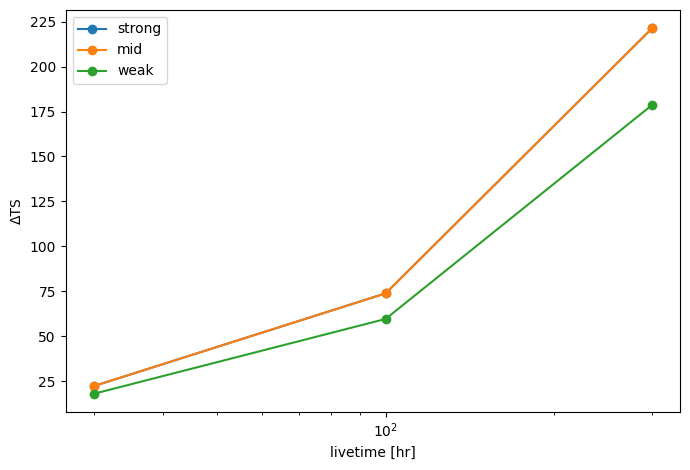

In [39]:

if len(scan_rows) > 0:
    import pandas as pd
    df_scan = pd.DataFrame(scan_rows)
    display(df_scan)

    plt.figure(figsize=(7, 4.8))
    for label in ["strong", "mid", "weak"]:
        sub = df_scan[df_scan["case"] == label].sort_values("livetime_hr")
        if len(sub) > 0:
            plt.plot(sub["livetime_hr"], sub["delta_ts"], marker="o", label=label)
    plt.xscale("log")
    plt.xlabel("livetime [hr]")
    plt.ylabel("ΔTS")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No scan output yet. Complete IRF wiring first.")


## Section 10. What to report after this notebook

After running this notebook, the four key takeaways to organize are:

1. **Template realism**: the diffusion / streaming 2D spatial templates now enter the CTA map-analysis chain successfully;
2. **IRF realism**: under realistic exposure / PSF / background conditions, does the strong case remain distinguishable, flatten out, or weaken strongly?
3. **Nuisance realism**: after releasing amplitude and background freedom, how much `ΔTS` remains?
4. **Feasibility boundary**: how much exposure is required before the strong / mid / weak cases begin to show useful distinguishability?

If the strong case still survives here, then the project has advanced from:

> an idea that mainly looks like a feasibility sketch

to:

> a distinguishability study supported by a realistic instrument-analysis chain

The most natural next step would then be to consolidate this notebook into:

- a cluster-specific version (real target cluster)
- a realistic spectral normalization
- a joint multi-energy template fit
- a systematic-error budget


In [40]:
# Monte Carlo robustness test:
# repeat the distinguishability fit with Poisson fluctuations
# to estimate the spread of ΔTS around the Asimov expectation.
def run_case_scan_mc(case_label, livetime=100, spectral_model=None, n_mc=20, seed0=0):
    rows = []
    if not GAMMAPY_AVAILABLE:
        return rows

    ds_empty = build_empty_dataset(name=f"mc-{case_label}-{livetime}h", livetime=livetime * u.hr)
    ds0, obs0 = attach_real_irfs_to_dataset(
        ds_empty,
        IRF_PATH,
        livetime=livetime * u.hr,
        pointing_icrs=POINTING_ICRS,
        obs_id=OBS_ID + 1000 + int(livetime),
        site=CTA_SITE,
    )

    model_D, model_S = build_competing_models(case_label, spectral_model)

    for i in range(n_mc):
        out_DD = inject_truth_and_fit(ds0, model_D, model_D, asimov=False, random_state=seed0 + i)
        out_DS = inject_truth_and_fit(ds0, model_D, model_S, asimov=False, random_state=seed0 + i)

        delta_ts = out_DS["stat_sum"] - out_DD["stat_sum"]

        rows.append({
            "case": case_label,
            "livetime_hr": livetime,
            "mc_id": i,
            "delta_ts": float(delta_ts),
            "mode": "Poisson-MC",
        })

    return rows


In [ ]:
mc_rows = run_case_scan_mc("strong", livetime=100, spectral_model=spectral_template, n_mc=20)
mc_df = pd.DataFrame(mc_rows)
mc_df.describe()

Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)
